# Isovist (Visibility) Analysis with topologic_fast

This notebook demonstrates isovist analysis concepts using topologic_fast.

An **isovist** is the set of all points visible from a particular location in a space. Isovist analysis is fundamental in:
- Architecture and urban design
- Environmental psychology
- Wayfinding and navigation
- Security and surveillance

We will:
1. Create a 2D floor plan with obstacles
2. Compute visibility polygons (isovists) from viewpoints
3. Calculate isovist metrics
4. Visualize visibility analysis

**Note:** This is adapted from topologicpy's Isovist_Metrics tutorial. Some advanced isovist features may not be available in topologic_fast, so we implement core concepts manually.

In [1]:
# Import libraries
import topologic_fast as tf
import plotly.graph_objects as go
import numpy as np
import math

## Isovist Metrics Overview

Common isovist metrics include:

| Metric | Description |
|--------|-------------|
| **Area** | Total visible area from viewpoint |
| **Perimeter** | Length of visibility boundary |
| **Compactness** | P^2 / (4*pi*A) - how circular the isovist is |
| **Max Radial (d_max)** | Longest sightline |
| **Min Radial (d_min)** | Shortest sightline |
| **Avg Radial (d_avg)** | Average sightline length |
| **Drift** | Distance from viewpoint to centroid |
| **Occlusivity** | Proportion of boundary not defined by walls |
| **Variance** | Variation in radial lengths |

## Create a Floor Plan with Obstacles

We'll create a simple room with rectangular obstacles.

In [2]:
# Define room boundary (10x10 square)
room_boundary = [
    (-5, -5), (5, -5), (5, 5), (-5, 5)
]

# Define obstacles (list of polygons)
obstacles = [
    # Obstacle 1: Rectangle in upper right
    [(2, 1.5), (4, 1.5), (4, 3.5), (2, 3.5)],
    # Obstacle 2: Rectangle in lower area
    [(0, -3), (4, -3), (4, -1), (0, -1)],
    # Obstacle 3: L-shaped obstacle on left
    [(-4, -2), (-2, -2), (-2, 0), (-3, 0), (-3, 2), (-4, 2)],
]

# Colors for visualization
obstacle_colors = ['red', 'blue', 'green']

print(f"Room: 10x10 units")
print(f"Number of obstacles: {len(obstacles)}")

Room: 10x10 units
Number of obstacles: 3


## Implement Ray Casting for Visibility

We'll implement a simple ray-casting algorithm to compute the isovist polygon.

In [3]:
def get_all_edges(boundary, obstacles):
    """Get all edges from boundary and obstacles."""
    edges = []
    
    # Boundary edges
    for i in range(len(boundary)):
        p1 = boundary[i]
        p2 = boundary[(i + 1) % len(boundary)]
        edges.append((p1, p2, 'boundary'))
    
    # Obstacle edges
    for obs_idx, obs in enumerate(obstacles):
        for i in range(len(obs)):
            p1 = obs[i]
            p2 = obs[(i + 1) % len(obs)]
            edges.append((p1, p2, f'obstacle_{obs_idx}'))
    
    return edges

def line_intersection(p1, p2, p3, p4):
    """Find intersection point of two line segments.
    Returns (t, u, point) where t and u are parameters [0,1] if intersection exists.
    """
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    x4, y4 = p4
    
    denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(denom) < 1e-10:
        return None
    
    t = ((x1 - x3) * (y3 - y4) - (y1 - y3) * (x3 - x4)) / denom
    u = -((x1 - x2) * (y1 - y3) - (y1 - y2) * (x1 - x3)) / denom
    
    if 0 <= t <= 1 and 0 <= u <= 1:
        x = x1 + t * (x2 - x1)
        y = y1 + t * (y2 - y1)
        return (t, u, (x, y))
    
    return None

def cast_ray(origin, angle, edges, max_dist=100):
    """Cast a ray from origin at given angle, return closest intersection."""
    dx = math.cos(angle)
    dy = math.sin(angle)
    
    ray_end = (origin[0] + dx * max_dist, origin[1] + dy * max_dist)
    
    closest_dist = max_dist
    closest_point = ray_end
    hit_type = 'none'
    
    for edge in edges:
        p1, p2, edge_type = edge
        result = line_intersection(origin, ray_end, p1, p2)
        
        if result:
            t, u, point = result
            dist = t * max_dist
            if 0 < dist < closest_dist:
                closest_dist = dist
                closest_point = point
                hit_type = edge_type
    
    return closest_point, closest_dist, hit_type

def compute_isovist(viewpoint, edges, num_rays=360, fov=360, direction=0):
    """
    Compute isovist polygon from a viewpoint.
    
    Parameters:
    - viewpoint: (x, y) coordinates
    - edges: list of (p1, p2, type) tuples
    - num_rays: number of rays to cast
    - fov: field of view in degrees
    - direction: view direction in degrees (0 = right, 90 = up)
    
    Returns:
    - list of (x, y) points forming the isovist polygon
    - list of distances
    - list of hit types
    """
    points = []
    distances = []
    hit_types = []
    
    start_angle = math.radians(direction - fov / 2)
    end_angle = math.radians(direction + fov / 2)
    
    for i in range(num_rays):
        angle = start_angle + (end_angle - start_angle) * i / (num_rays - 1)
        point, dist, hit_type = cast_ray(viewpoint, angle, edges)
        points.append(point)
        distances.append(dist)
        hit_types.append(hit_type)
    
    return points, distances, hit_types

# Get all edges
all_edges = get_all_edges(room_boundary, obstacles)
print(f"Total edges: {len(all_edges)}")

Total edges: 18


## Compute Isovist Metrics

In [6]:
def compute_isovist_metrics(viewpoint, isovist_points, distances, hit_types):
    """
    Compute various isovist metrics.
    """
    metrics = {}
    
    # Viewpoint
    metrics['viewpoint'] = viewpoint
    
    # Distance metrics
    metrics['d_max'] = max(distances)
    metrics['d_min'] = min(distances)
    metrics['d_avg'] = sum(distances) / len(distances)
    
    # Find max/min vertices
    max_idx = distances.index(max(distances))
    min_idx = distances.index(min(distances))
    metrics['v_max'] = isovist_points[max_idx]
    metrics['v_min'] = isovist_points[min_idx]
    
    # Compute area using shoelace formula
    n = len(isovist_points)
    area = 0
    for i in range(n):
        j = (i + 1) % n
        area += isovist_points[i][0] * isovist_points[j][1]
        area -= isovist_points[j][0] * isovist_points[i][1]
    metrics['area'] = abs(area) / 2
    
    # Compute perimeter
    perimeter = 0
    for i in range(n):
        j = (i + 1) % n
        dx = isovist_points[j][0] - isovist_points[i][0]
        dy = isovist_points[j][1] - isovist_points[i][1]
        perimeter += math.sqrt(dx**2 + dy**2)
    metrics['perimeter'] = perimeter
    
    # Compactness: P^2 / (4*pi*A)
    if metrics['area'] > 0:
        metrics['compactness'] = (perimeter ** 2) / (4 * math.pi * metrics['area'])
    else:
        metrics['compactness'] = float('inf')
    
    # Centroid
    cx = sum(p[0] for p in isovist_points) / n
    cy = sum(p[1] for p in isovist_points) / n
    metrics['centroid'] = (cx, cy)
    
    # Drift: distance from viewpoint to centroid
    metrics['drift'] = math.sqrt((cx - viewpoint[0])**2 + (cy - viewpoint[1])**2)
    
    # Occlusivity: proportion of boundary not from walls
    boundary_hits = sum(1 for ht in hit_types if ht == 'boundary')
    metrics['occlusivity'] = 1 - (boundary_hits / len(hit_types))
    
    # Variance of radial lengths
    mean_dist = metrics['d_avg']
    variance = sum((d - mean_dist)**2 for d in distances) / len(distances)
    metrics['variance'] = math.sqrt(variance)
    
    # Skewness
    if metrics['variance'] > 0:
        skewness = sum((d - mean_dist)**3 for d in distances) / len(distances)
        metrics['skewness'] = np.cbrt(skewness)
    else:
        metrics['skewness'] = 0
    
    return metrics

# Test with a viewpoint
test_viewpoint = (-1, 3)
points, distances, hit_types = compute_isovist(test_viewpoint, all_edges, num_rays=1000)
metrics = compute_isovist_metrics(test_viewpoint, points, distances, hit_types)

print("Isovist Metrics:")
print("=" * 50)
for key, value in metrics.items():
    if isinstance(value, float):
        print(f"  {key:15s}: {value:.4f}")
    else:
        print(f"  {key:15s}: {value}")

Isovist Metrics:
  viewpoint      : (-1, 3)
  d_max          : 8.1520
  d_min          : 2.0000
  d_avg          : 3.8015
  v_max          : (-2.5667945196166277, -5.0)
  v_min          : (-0.9968552600173929, 5.0)
  area           : 53.7510
  perimeter      : 46.6481
  compactness    : 3.2216
  centroid       : (-0.7604532984403292, 2.333256437476067)
  drift          : 0.7085
  occlusivity    : 0.3830
  variance       : 1.6360
  skewness       : 1.7378


## Visualize the Isovist

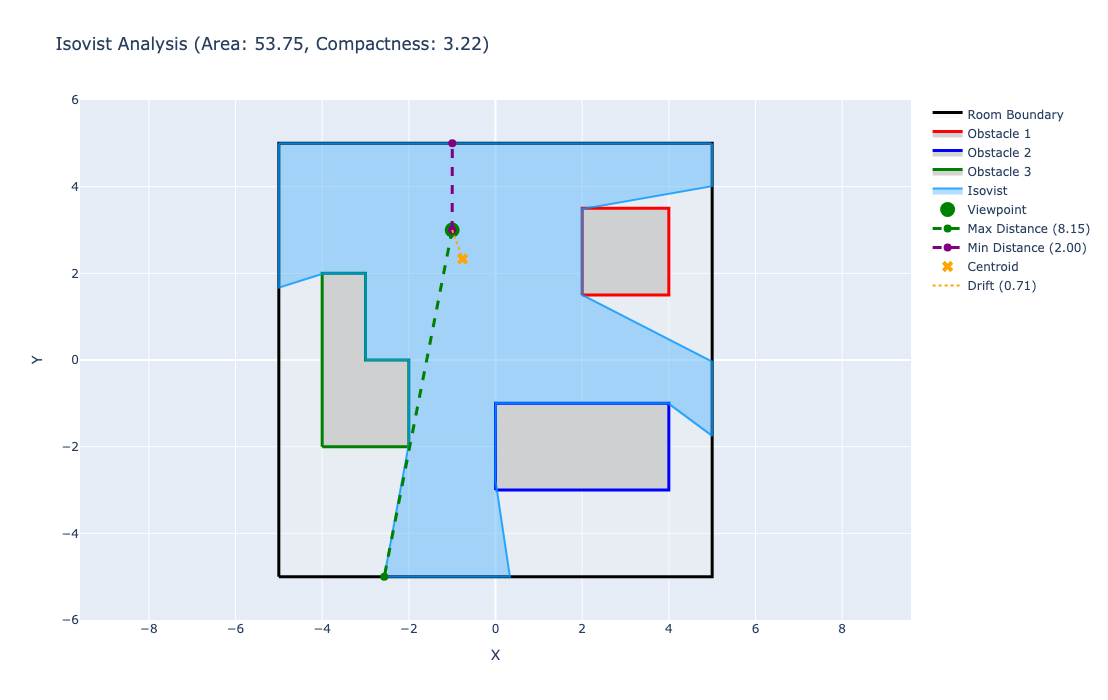

In [7]:
def visualize_isovist(boundary, obstacles, viewpoint, isovist_points, metrics, obstacle_colors):
    """
    Create a visualization of the floor plan, obstacles, and isovist.
    """
    fig = go.Figure()
    
    # Draw room boundary
    bx = [p[0] for p in boundary] + [boundary[0][0]]
    by = [p[1] for p in boundary] + [boundary[0][1]]
    fig.add_trace(go.Scatter(
        x=bx, y=by,
        mode='lines',
        line=dict(color='black', width=3),
        name='Room Boundary',
        fill='toself',
        fillcolor='rgba(240,240,240,0.3)'
    ))
    
    # Draw obstacles
    for i, obs in enumerate(obstacles):
        ox = [p[0] for p in obs] + [obs[0][0]]
        oy = [p[1] for p in obs] + [obs[0][1]]
        fig.add_trace(go.Scatter(
            x=ox, y=oy,
            mode='lines',
            line=dict(color=obstacle_colors[i], width=3),
            name=f'Obstacle {i+1}',
            fill='toself',
            fillcolor=f'rgba(200,200,200,0.8)'
        ))
    
    # Draw isovist polygon
    ix = [p[0] for p in isovist_points] + [isovist_points[0][0]]
    iy = [p[1] for p in isovist_points] + [isovist_points[0][1]]
    fig.add_trace(go.Scatter(
        x=ix, y=iy,
        mode='lines',
        line=dict(color='rgba(0,150,255,0.8)', width=2),
        name='Isovist',
        fill='toself',
        fillcolor='rgba(0,150,255,0.3)'
    ))
    
    # Draw viewpoint
    fig.add_trace(go.Scatter(
        x=[viewpoint[0]],
        y=[viewpoint[1]],
        mode='markers',
        marker=dict(size=15, color='green', symbol='circle'),
        name='Viewpoint'
    ))
    
    # Draw max distance line
    fig.add_trace(go.Scatter(
        x=[viewpoint[0], metrics['v_max'][0]],
        y=[viewpoint[1], metrics['v_max'][1]],
        mode='lines+markers',
        line=dict(color='green', width=3, dash='dash'),
        marker=dict(size=8),
        name=f"Max Distance ({metrics['d_max']:.2f})"
    ))
    
    # Draw min distance line
    fig.add_trace(go.Scatter(
        x=[viewpoint[0], metrics['v_min'][0]],
        y=[viewpoint[1], metrics['v_min'][1]],
        mode='lines+markers',
        line=dict(color='purple', width=3, dash='dash'),
        marker=dict(size=8),
        name=f"Min Distance ({metrics['d_min']:.2f})"
    ))
    
    # Draw centroid
    fig.add_trace(go.Scatter(
        x=[metrics['centroid'][0]],
        y=[metrics['centroid'][1]],
        mode='markers',
        marker=dict(size=10, color='orange', symbol='x'),
        name='Centroid'
    ))
    
    # Draw drift line (viewpoint to centroid)
    fig.add_trace(go.Scatter(
        x=[viewpoint[0], metrics['centroid'][0]],
        y=[viewpoint[1], metrics['centroid'][1]],
        mode='lines',
        line=dict(color='orange', width=2, dash='dot'),
        name=f"Drift ({metrics['drift']:.2f})"
    ))
    
    fig.update_layout(
        title=f"Isovist Analysis (Area: {metrics['area']:.2f}, Compactness: {metrics['compactness']:.2f})",
        xaxis=dict(title='X', scaleanchor='y', scaleratio=1, range=[-6, 6]),
        yaxis=dict(title='Y', range=[-6, 6]),
        width=800,
        height=700,
        legend=dict(x=1.02, y=1)
    )
    
    return fig

fig_isovist = visualize_isovist(room_boundary, obstacles, test_viewpoint, points, metrics, obstacle_colors)
fig_isovist.show()

## Isovist with Limited Field of View

In [8]:
# Compute isovist with limited FOV
viewpoint_fov = (-1, 3)
fov = 140  # degrees
direction = -45  # looking toward lower right

points_fov, distances_fov, hit_types_fov = compute_isovist(
    viewpoint_fov, all_edges, 
    num_rays=140, 
    fov=fov, 
    direction=direction
)

# Add viewpoint to close the polygon
points_fov_closed = [viewpoint_fov] + points_fov + [viewpoint_fov]

metrics_fov = compute_isovist_metrics(viewpoint_fov, points_fov, distances_fov, hit_types_fov)
metrics_fov['fov'] = fov
metrics_fov['direction'] = direction

print(f"Isovist with FOV={fov} degrees, Direction={direction} degrees")
print("=" * 50)
for key, value in metrics_fov.items():
    if isinstance(value, float):
        print(f"  {key:15s}: {value:.4f}")
    else:
        print(f"  {key:15s}: {value}")

Isovist with FOV=140 degrees, Direction=-45 degrees
  viewpoint      : (-1, 3)
  d_max          : 8.1470
  d_min          : 3.0000
  d_avg          : 5.0791
  v_max          : (-2.5404530032163004, -4.999999999999999)
  v_min          : (2.0, 2.99058272490246)
  area           : 30.2994
  perimeter      : 37.7628
  compactness    : 3.7453
  centroid       : (1.5285933268236085, 0.0015448385284732914)
  drift          : 3.9223
  occlusivity    : 0.6500
  variance       : 1.7852
  skewness       : 1.3324
  fov            : 140
  direction      : -45


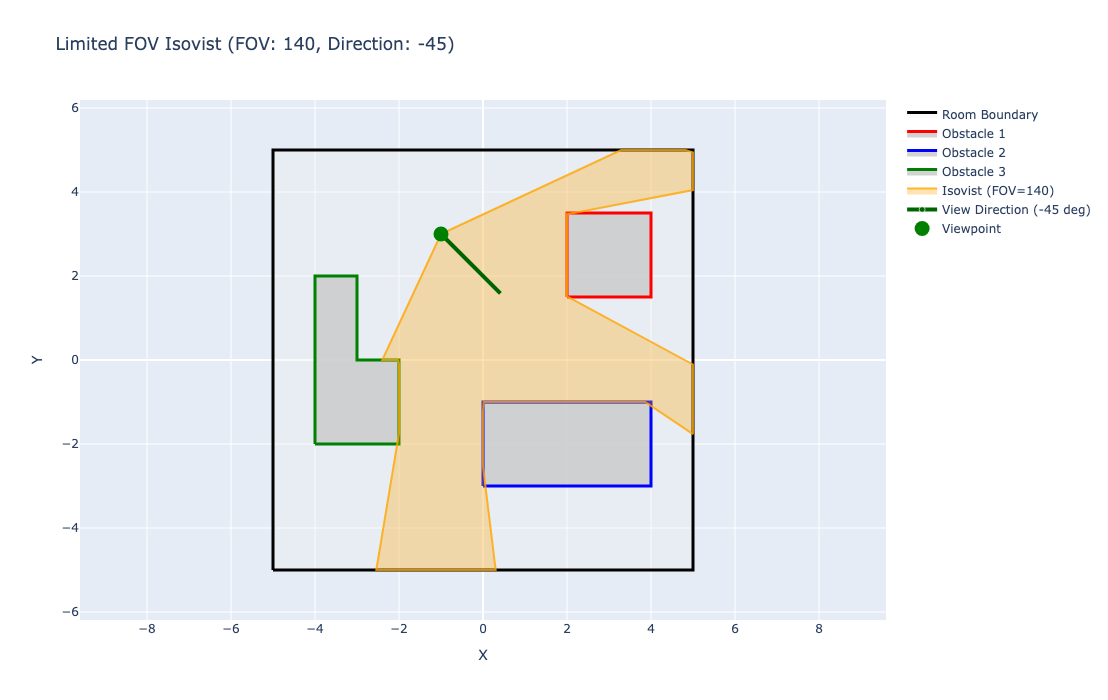

In [9]:
def visualize_fov_isovist(boundary, obstacles, viewpoint, isovist_points, metrics, obstacle_colors, fov, direction):
    """Visualize isovist with limited field of view."""
    fig = go.Figure()
    
    # Draw room boundary
    bx = [p[0] for p in boundary] + [boundary[0][0]]
    by = [p[1] for p in boundary] + [boundary[0][1]]
    fig.add_trace(go.Scatter(
        x=bx, y=by,
        mode='lines',
        line=dict(color='black', width=3),
        name='Room Boundary',
        fill='toself',
        fillcolor='rgba(240,240,240,0.3)'
    ))
    
    # Draw obstacles
    for i, obs in enumerate(obstacles):
        ox = [p[0] for p in obs] + [obs[0][0]]
        oy = [p[1] for p in obs] + [obs[0][1]]
        fig.add_trace(go.Scatter(
            x=ox, y=oy,
            mode='lines',
            line=dict(color=obstacle_colors[i], width=3),
            name=f'Obstacle {i+1}',
            fill='toself',
            fillcolor='rgba(200,200,200,0.8)'
        ))
    
    # Draw FOV isovist (including viewpoint to close)
    closed_points = [viewpoint] + list(isovist_points) + [viewpoint]
    ix = [p[0] for p in closed_points]
    iy = [p[1] for p in closed_points]
    fig.add_trace(go.Scatter(
        x=ix, y=iy,
        mode='lines',
        line=dict(color='rgba(255,165,0,0.8)', width=2),
        name=f'Isovist (FOV={fov})',
        fill='toself',
        fillcolor='rgba(255,165,0,0.3)'
    ))
    
    # Draw direction arrow
    arrow_len = 2
    dir_rad = math.radians(direction)
    arrow_end = (viewpoint[0] + arrow_len * math.cos(dir_rad),
                 viewpoint[1] + arrow_len * math.sin(dir_rad))
    fig.add_trace(go.Scatter(
        x=[viewpoint[0], arrow_end[0]],
        y=[viewpoint[1], arrow_end[1]],
        mode='lines+markers',
        line=dict(color='darkgreen', width=4),
        marker=dict(size=[12, 0], symbol=['circle', 'arrow-up']),
        name=f'View Direction ({direction} deg)'
    ))
    
    # Draw viewpoint
    fig.add_trace(go.Scatter(
        x=[viewpoint[0]],
        y=[viewpoint[1]],
        mode='markers',
        marker=dict(size=15, color='green', symbol='circle'),
        name='Viewpoint'
    ))
    
    fig.update_layout(
        title=f"Limited FOV Isovist (FOV: {fov}, Direction: {direction})",
        xaxis=dict(title='X', scaleanchor='y', scaleratio=1, range=[-6, 6]),
        yaxis=dict(title='Y', range=[-6, 6]),
        width=800,
        height=700,
        legend=dict(x=1.02, y=1)
    )
    
    return fig

fig_fov = visualize_fov_isovist(
    room_boundary, obstacles, viewpoint_fov, 
    points_fov, metrics_fov, obstacle_colors,
    fov, direction
)
fig_fov.show()

## Visibility Heat Map

Compute isovist metrics for a grid of viewpoints to create a visibility analysis map.

In [10]:
def point_in_polygon(point, polygon):
    """Check if a point is inside a polygon using ray casting."""
    x, y = point
    n = len(polygon)
    inside = False
    
    j = n - 1
    for i in range(n):
        xi, yi = polygon[i]
        xj, yj = polygon[j]
        
        if ((yi > y) != (yj > y)) and (x < (xj - xi) * (y - yi) / (yj - yi) + xi):
            inside = not inside
        j = i
    
    return inside

def compute_visibility_grid(boundary, obstacles, resolution=20):
    """Compute visibility metrics on a grid."""
    # Get bounds
    xs = [p[0] for p in boundary]
    ys = [p[1] for p in boundary]
    x_range = np.linspace(min(xs) + 0.5, max(xs) - 0.5, resolution)
    y_range = np.linspace(min(ys) + 0.5, max(ys) - 0.5, resolution)
    
    edges = get_all_edges(boundary, obstacles)
    
    # Initialize grids
    area_grid = np.zeros((resolution, resolution))
    compactness_grid = np.zeros((resolution, resolution))
    drift_grid = np.zeros((resolution, resolution))
    
    for i, x in enumerate(x_range):
        for j, y in enumerate(y_range):
            viewpoint = (x, y)
            
            # Check if viewpoint is inside any obstacle
            inside_obstacle = False
            for obs in obstacles:
                if point_in_polygon(viewpoint, obs):
                    inside_obstacle = True
                    break
            
            if inside_obstacle:
                area_grid[j, i] = np.nan
                compactness_grid[j, i] = np.nan
                drift_grid[j, i] = np.nan
            else:
                points, distances, hit_types = compute_isovist(viewpoint, edges, num_rays=72)
                metrics = compute_isovist_metrics(viewpoint, points, distances, hit_types)
                
                area_grid[j, i] = metrics['area']
                compactness_grid[j, i] = min(metrics['compactness'], 5)  # Cap for visualization
                drift_grid[j, i] = metrics['drift']
    
    return x_range, y_range, area_grid, compactness_grid, drift_grid

# Compute grid (this may take a moment)
print("Computing visibility grid...")
x_range, y_range, area_grid, compactness_grid, drift_grid = compute_visibility_grid(
    room_boundary, obstacles, resolution=25
)
print("Done!")

Computing visibility grid...
Done!


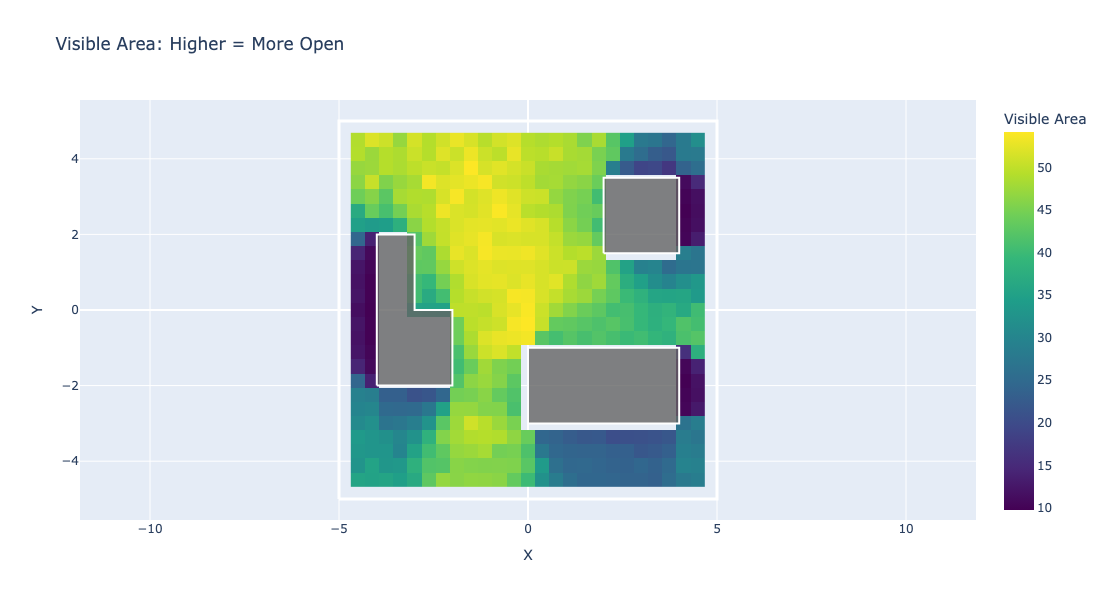

In [11]:
def visualize_heatmap(x_range, y_range, grid, boundary, obstacles, title, colorscale='Viridis'):
    """Create a heatmap visualization with obstacles overlaid."""
    fig = go.Figure()
    
    # Heatmap
    fig.add_trace(go.Heatmap(
        x=x_range,
        y=y_range,
        z=grid,
        colorscale=colorscale,
        colorbar=dict(title=title.split(':')[0]),
        hoverongaps=False
    ))
    
    # Draw room boundary
    bx = [p[0] for p in boundary] + [boundary[0][0]]
    by = [p[1] for p in boundary] + [boundary[0][1]]
    fig.add_trace(go.Scatter(
        x=bx, y=by,
        mode='lines',
        line=dict(color='white', width=3),
        showlegend=False
    ))
    
    # Draw obstacles
    for obs in obstacles:
        ox = [p[0] for p in obs] + [obs[0][0]]
        oy = [p[1] for p in obs] + [obs[0][1]]
        fig.add_trace(go.Scatter(
            x=ox, y=oy,
            mode='lines',
            line=dict(color='white', width=2),
            fill='toself',
            fillcolor='rgba(100,100,100,0.8)',
            showlegend=False
        ))
    
    fig.update_layout(
        title=title,
        xaxis=dict(title='X', scaleanchor='y', scaleratio=1),
        yaxis=dict(title='Y'),
        width=700,
        height=600
    )
    
    return fig

# Visualize area heatmap
fig_area = visualize_heatmap(
    x_range, y_range, area_grid, 
    room_boundary, obstacles,
    'Visible Area: Higher = More Open',
    colorscale='Viridis'
)
fig_area.show()

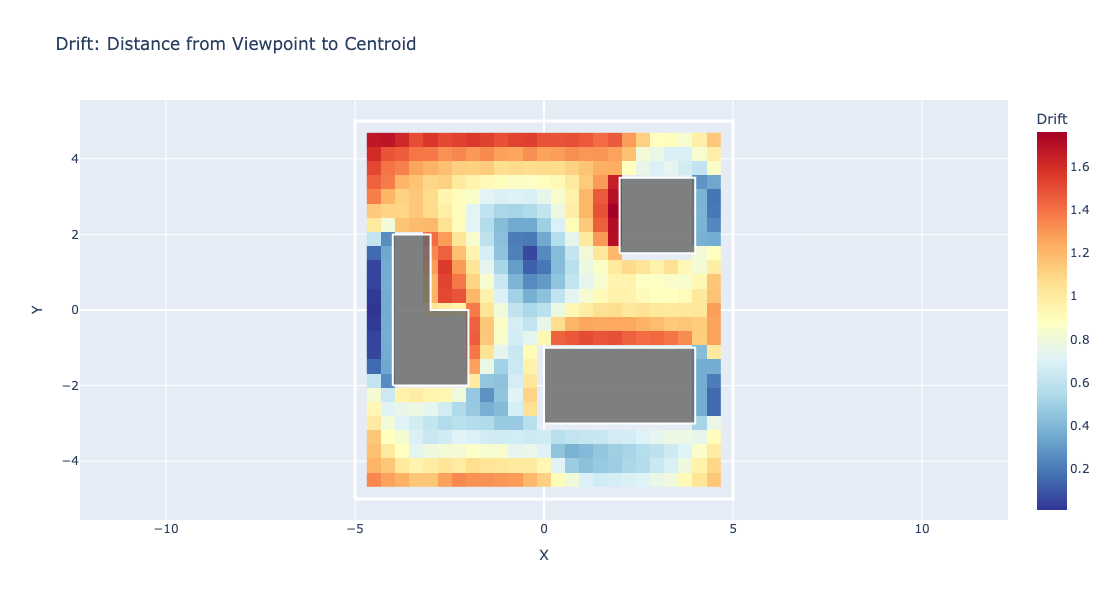

In [12]:
# Visualize drift heatmap
fig_drift = visualize_heatmap(
    x_range, y_range, drift_grid, 
    room_boundary, obstacles,
    'Drift: Distance from Viewpoint to Centroid',
    colorscale='RdYlBu_r'
)
fig_drift.show()

## Compare Multiple Viewpoints

In [13]:
# Define several viewpoints to compare
viewpoints = [
    (0, 0),      # Center
    (-3, 3),     # Upper left
    (3, -3),     # Lower right
    (-1, -3.5),  # Near obstacle
]

viewpoint_names = ['Center', 'Upper Left', 'Lower Right', 'Near Obstacle']
viewpoint_colors = ['green', 'blue', 'red', 'purple']

# Compute isovists and metrics for each
all_metrics = []
all_points = []

for vp in viewpoints:
    pts, dists, hits = compute_isovist(vp, all_edges, num_rays=180)
    m = compute_isovist_metrics(vp, pts, dists, hits)
    all_metrics.append(m)
    all_points.append(pts)

# Print comparison table
print("Viewpoint Comparison:")
print("=" * 80)
print(f"{'Location':<20} {'Area':>10} {'Compactness':>12} {'Drift':>10} {'d_max':>10} {'d_min':>10}")
print("-" * 80)
for name, m in zip(viewpoint_names, all_metrics):
    print(f"{name:<20} {m['area']:>10.2f} {m['compactness']:>12.2f} {m['drift']:>10.2f} {m['d_max']:>10.2f} {m['d_min']:>10.2f}")

Viewpoint Comparison:
Location                   Area  Compactness      Drift      d_max      d_min
--------------------------------------------------------------------------------
Center                    54.04         2.84       0.59       6.98       1.00
Upper Left                50.63         3.25       1.10       9.16       1.00
Lower Right               27.98         2.21       0.70       8.22       1.00
Near Obstacle             49.65         3.18       0.70       9.08       1.12


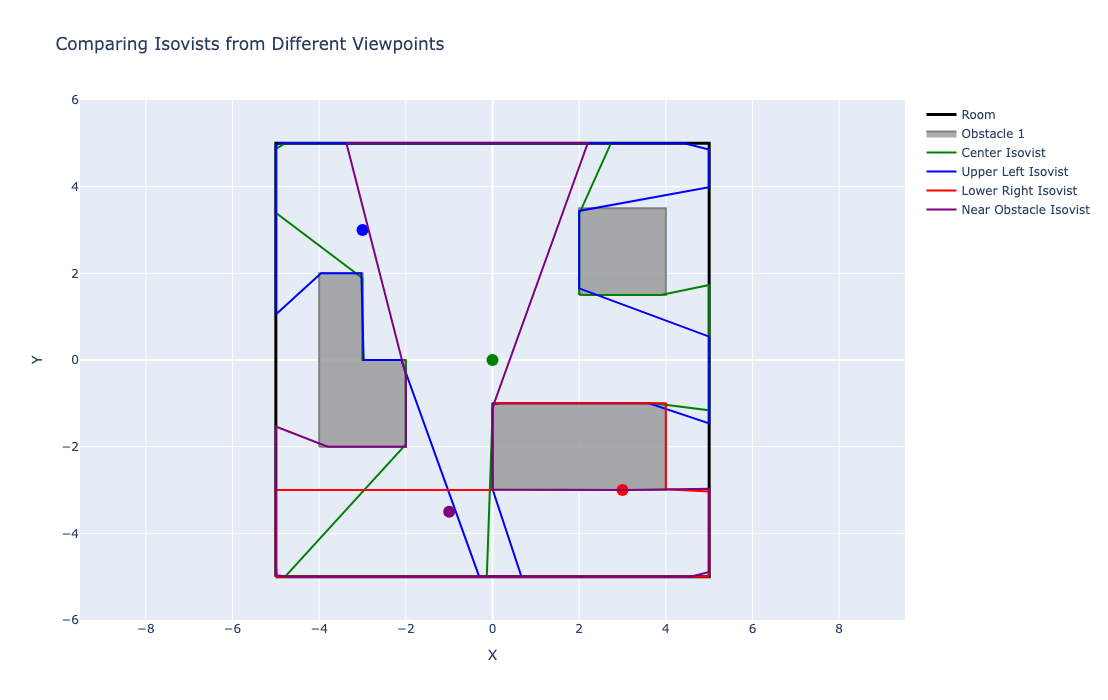

In [14]:
# Visualize all isovists overlaid
fig = go.Figure()

# Draw room boundary
bx = [p[0] for p in room_boundary] + [room_boundary[0][0]]
by = [p[1] for p in room_boundary] + [room_boundary[0][1]]
fig.add_trace(go.Scatter(
    x=bx, y=by,
    mode='lines',
    line=dict(color='black', width=3),
    name='Room'
))

# Draw obstacles
for i, obs in enumerate(obstacles):
    ox = [p[0] for p in obs] + [obs[0][0]]
    oy = [p[1] for p in obs] + [obs[0][1]]
    fig.add_trace(go.Scatter(
        x=ox, y=oy,
        mode='lines',
        line=dict(color='gray', width=2),
        fill='toself',
        fillcolor='rgba(150,150,150,0.8)',
        name=f'Obstacle {i+1}' if i == 0 else None,
        showlegend=(i == 0)
    ))

# Draw isovists
for i, (vp, pts, name, color) in enumerate(zip(viewpoints, all_points, viewpoint_names, viewpoint_colors)):
    ix = [p[0] for p in pts] + [pts[0][0]]
    iy = [p[1] for p in pts] + [pts[0][1]]
    
    # Isovist boundary only (no fill to see overlaps)
    fig.add_trace(go.Scatter(
        x=ix, y=iy,
        mode='lines',
        line=dict(color=color, width=2),
        name=f'{name} Isovist'
    ))
    
    # Viewpoint marker
    fig.add_trace(go.Scatter(
        x=[vp[0]], y=[vp[1]],
        mode='markers',
        marker=dict(size=12, color=color, symbol='circle'),
        name=f'{name} VP',
        showlegend=False
    ))

fig.update_layout(
    title='Comparing Isovists from Different Viewpoints',
    xaxis=dict(title='X', scaleanchor='y', scaleratio=1, range=[-6, 6]),
    yaxis=dict(title='Y', range=[-6, 6]),
    width=800,
    height=700,
    legend=dict(x=1.02, y=1)
)

fig.show()

## Note on topologic_fast Isovist Support

The original topologicpy notebook uses dedicated isovist methods:

**Features not available in topologic_fast:**
- `Face.Isovist()` - Compute isovist polygon with full metrics
- Dictionary-based edge styling for visualization
- `transferDictionaries` parameter for edge type tracking
- Built-in `triangles` option for visibility ray visualization
- CSS color names via `Color.CSSNamedColors()`

However, this notebook demonstrates the core isovist concepts:
1. **Ray Casting** - Finding visibility boundaries
2. **Metric Computation** - Area, perimeter, compactness, drift
3. **FOV Support** - Limited field of view analysis
4. **Visibility Maps** - Grid-based isovist analysis

These can be implemented using Python's math operations and topologic_fast's geometry primitives.

## Summary

This notebook demonstrated isovist (visibility) analysis:

1. **Floor Plan Creation** - Boundary and obstacle definitions
2. **Ray Casting Algorithm** - Computing visibility polygons
3. **Isovist Metrics** - Area, perimeter, compactness, drift, etc.
4. **Limited FOV** - Directional visibility analysis
5. **Visibility Heat Maps** - Grid-based spatial analysis
6. **Viewpoint Comparison** - Comparing different observation points

### Key Metrics Explained:
| Metric | Interpretation |
|--------|----------------|
| **Area** | How much space is visible (larger = more open) |
| **Compactness** | Shape regularity (1 = circle, >1 = irregular) |
| **Drift** | Offset of visual center from viewpoint |
| **d_max** | Longest sightline (vista potential) |
| **d_min** | Shortest sightline (enclosure feeling) |
| **Occlusivity** | Amount of view blocked by obstacles |

### Applications:
- **Architecture**: Understanding space perception
- **Urban Design**: Analyzing street visibility
- **Security**: Camera placement optimization
- **Gaming**: AI visibility and pathfinding
- **Wayfinding**: Navigation aid design